
*  David_Ribeiro_Prado_de_Lacerda_RM570350_fase3_cap1
*  Giselli_Mayumi_Takahashi_Yokoyama_RM572690_fase3_cap1
*  João_Otavio_Moraes_RM 573227_fase3_cap1
*  Renata_de_Almeida_Marinho_RM569342_fase3_cap1
*  Richard_Wrobel_dos_Santos_RM573998_fase3_cap1  



# Análise FarmTech Solutions

## 1. Importação das Bibliotecas

In [ ]:
# importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# carregar o dataset
df = pd.read_csv("Atividade_Cap10_produtos_agricolas.csv")

# visualizações iniciais do dataframe
print(df.head())

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


## 2. Análise Exploratória da Base

In [ ]:
#tamanho da base
df.shape

#tipo das variáveis
df.info()

#estatísticas gerais
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   N            10 non-null     int64 
 1   P            10 non-null     int64 
 2   K            10 non-null     int64 
 3   temperatura  10 non-null     object
 4   umidade      10 non-null     object
 5   ph           10 non-null     object
 6   chuva        10 non-null     object
 7   cultura      10 non-null     object
 8   irrigacao    10 non-null     object
dtypes: int64(3), object(6)
memory usage: 852.0+ bytes


,N,P,K
count,10.000000,10.000000,10.000000
mean,0.800000,0.600000,0.400000
std,0.421637,0.516398,0.516398
min,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000


## 3. Limpeza de Dados

In [ ]:
# Verifica valores nulos
df.isnull().sum()

,0
N,0
P,0
K,0
temperatura,0
umidade,0
ph,0
chuva,0
cultura,0
irrigacao,0


### Gráfico 1 - Distribuição das culturas

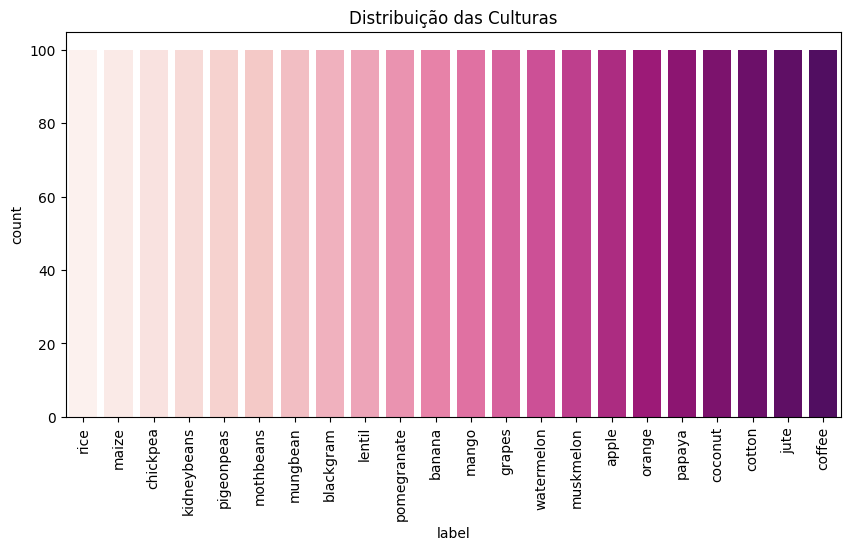

In [ ]:
#ignorando avisos
import warnings
warnings.filterwarnings('ignore')

#gráfico
plt.figure(figsize=(10,5))
sns.countplot(x='label', data=df, palette = "RdPu")
plt.xticks(rotation=90)
plt.title("Distribuição das Culturas")
plt.show()

### Gráfico 2 - Temperatura por cultura

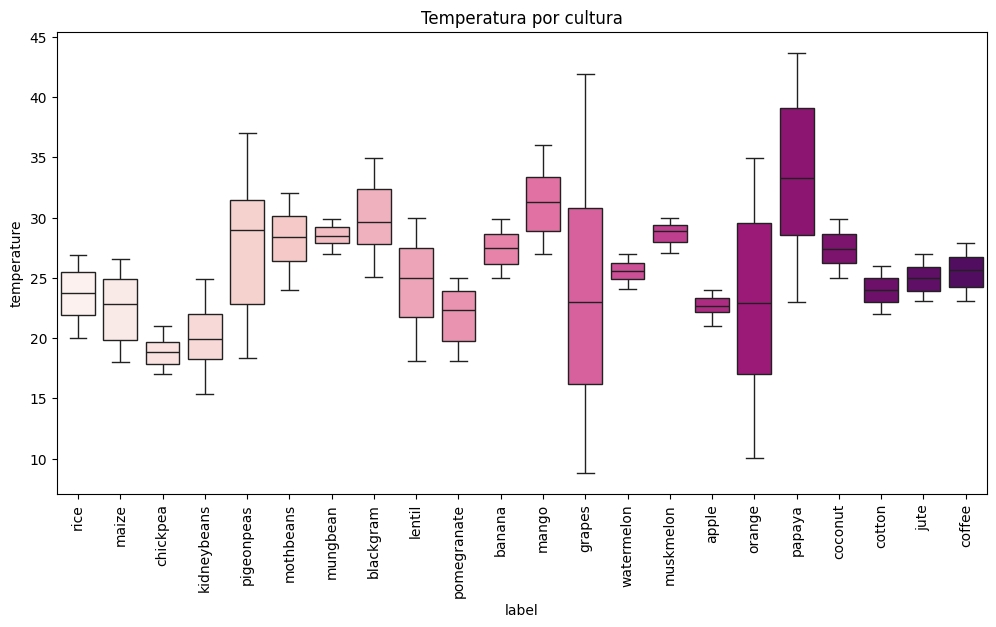

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='temperature', data=df, palette = 'RdPu')
plt.xticks(rotation=90)
plt.title("Temperatura por cultura")
plt.show()

### Gráfico 3 - Umidade X Temperatura

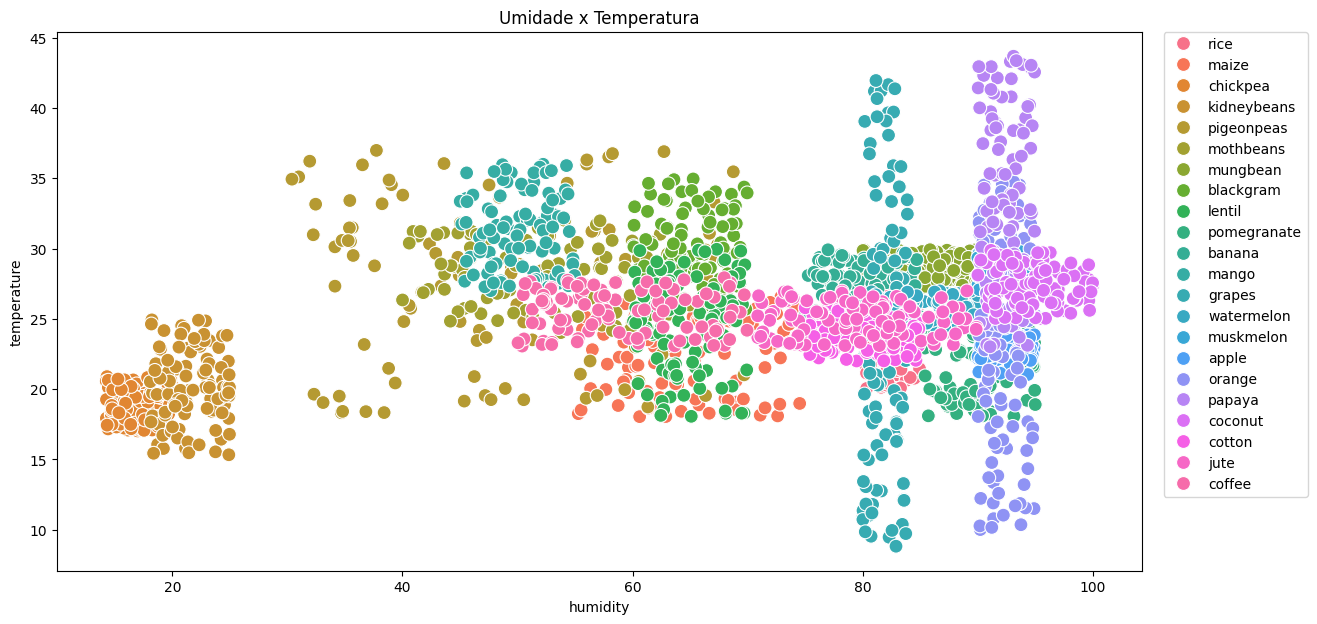

In [ ]:
plt.figure(figsize=(14,7))
sns.scatterplot(x='humidity', y='temperature', hue='label', data=df, s=100)
plt.title("Umidade x Temperatura")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left',borderaxespad=0)
plt.show()

### Gráfico 4 - Correlação das Variáveis

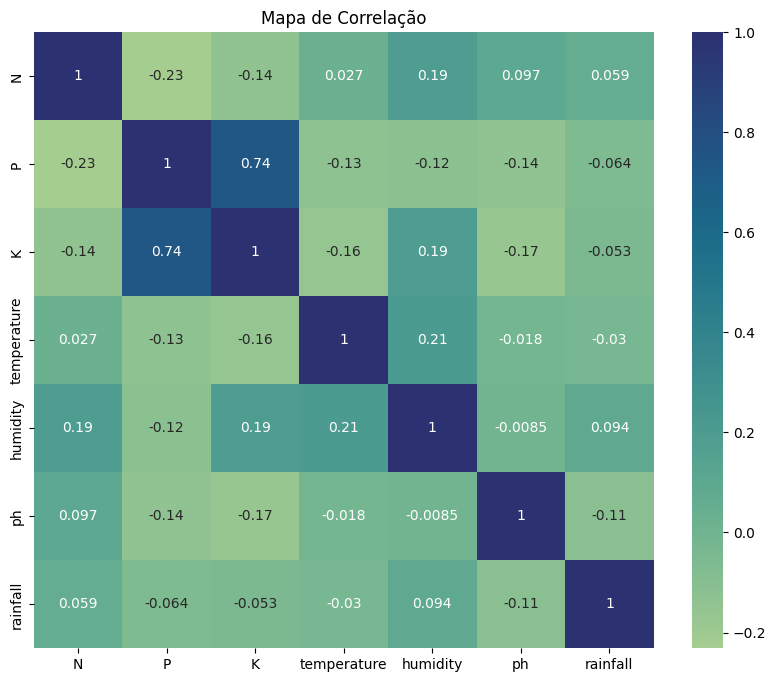

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop('label', axis=1).corr(),annot=True,cmap='crest')
plt.title("Mapa de Correlação")
plt.show()

### Gráfico 5 - Distribuição do PH

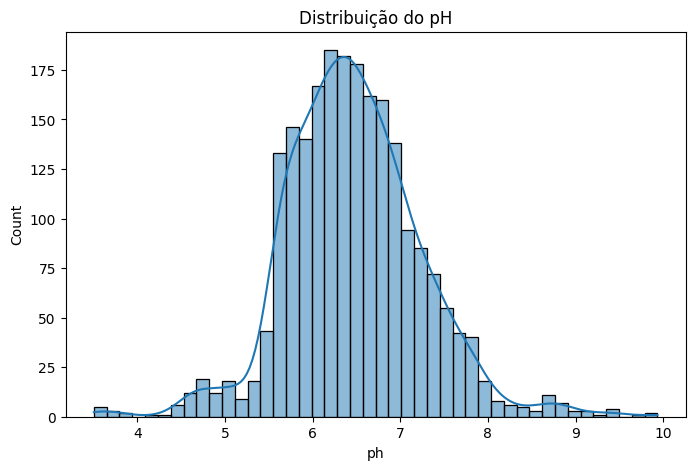

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['ph'], kde=True)

plt.title("Distribuição do pH")
plt.show()

## 4. Perfil Ideal Solo/Clima

In [ ]:
#cálculo médio das três culturas escolhidas
culturas = ['rice', 'maize', 'coffee']
perfil = df[df['label'].isin(culturas)]
perfil_medio = perfil.groupby('label').mean()
print(perfil_medio)

             N      P      K  temperature   humidity        ph    rainfall
label                                                                     
coffee  101.20  28.74  29.94    25.540477  58.869846  6.790308  158.066295
maize    77.76  48.44  19.79    22.389204  65.092249  6.245190   84.766988
rice     79.89  47.58  39.87    23.689332  82.272822  6.425471  236.181114


Café (Coffee)

A cultura do café apresentou preferência por solos com maior concentração de Potássio (K), nutriente essencial para o desenvolvimento dos frutos e melhoria da qualidade da produção.

Além disso, observou-se que o café se adapta melhor a temperaturas moderadas e ambientes com índices mais elevados de chuva, demonstrando maior necessidade hídrica em comparação com outras culturas analisadas.

Principais características observadas:

*   Maior concentração de Potássio (K)
*   Temperaturas moderadas
*   Alta necessidade de chuva
*   Umidade relativamente elevada


---


Milho (Maize)

O milho apresentou comportamento mais equilibrado em relação aos nutrientes NPK (Nitrogênio, Fósforo e Potássio), demonstrando boa adaptabilidade a diferentes condições de solo.

A análise também mostrou que essa cultura tolera temperaturas mais elevadas, característica importante para regiões mais quentes e de maior exposição solar.

Principais características observadas:
*   Equilíbrio nos níveis de NPK
*   Boa adaptação climática
*   Tolerância a temperaturas elevadas
*   Necessidade moderada de umidade


---


Arroz (Rice)

A cultura do arroz apresentou forte dependência de ambientes com alta umidade e elevados índices de chuva, características típicas de sistemas agrícolas alagados utilizados em sua produção.

Os dados também indicaram preferência por solos com boa disponibilidade de Nitrogênio (N), nutriente fundamental para o crescimento vegetativo da planta.

Além disso, o arroz demonstrou melhor desempenho em temperaturas estáveis e ambientes com grande disponibilidade hídrica.

Principais características observadas:
*   Alta necessidade de água
*   Elevados índices de chuva e umidade
*   Maior demanda de Nitrogênio (N)
*   Melhor desenvolvimento em ambientes úmidos

---

## 5. Análise Preditiva

In [ ]:
#separar as variáveis
X = df.drop('label', axis=1)
y = df['label']

#converter texto em números
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# dividir os dados em conjuntos de treino e teste (80% treino e 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

# padronizar os dados em torno da média
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### Modelo KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 9)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, pred_knn)
print(f"Acurácia KNN: {accuracy_score(y_test, pred_knn)*100:.2f}%")
print(classification_report(y_test, pred_knn, digits=2))

Acurácia KNN: 95.23%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      0.95      0.95        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.77      1.00      0.87        23
           9       0.91      1.00      0.95        20
          10       0.69      1.00      0.81        11
          11       1.00      0.95      0.98        21
          12       0.83      1.00      0.90        19
          13       1.00      0.83      0.91        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
      

### Modelo Decision Tree

In [ ]:
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)
acc_tree = accuracy_score(y_test, pred_tree)
print(f"Acurácia Decision Tree: {accuracy_score(y_test, pred_tree)*100:.2f}%")
print(classification_report(y_test, pred_tree, digits=2))

Acurácia Decision Tree: 98.41%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.91      0.87      0.89        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.92      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00       

### Modelo Random Forest

In [ ]:
forest = RandomForestClassifier()
forest.fit(X_train, y_train)
pred_forest = forest.predict(X_test)
acc_forest = accuracy_score(y_test, pred_forest)
print(f"Acurácia Random Forest: {accuracy_score(y_test, pred_forest)*100:.2f}%")
print(classification_report(y_test, pred_forest, digits=2))

Acurácia Random Forest: 99.32%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00       

### Modelo SVM com Kernell

In [ ]:
# SVM com Kernel Linear
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)
pred_linear = svm_linear.predict(X_test)
acc_linear = accuracy_score(y_test, pred_linear)
print(f"Acurácia SVM Linear: {accuracy_score(y_test, pred_linear)*100:.2f}%")
print(classification_report(y_test, pred_linear, digits=2))

Acurácia SVM Linear: 97.73%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.85      0.96      0.90        23
           9       0.91      1.00      0.95        20
          10       0.92      1.00      0.96        11
          11       1.00      0.95      0.98        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14

### Modelo Logistic Regression

In [ ]:
log = LogisticRegression(max_iter=500)
log.fit(X_train, y_train)
pred_log = log.predict(X_test)
acc_log = accuracy_score(y_test, pred_log)
print(f"Acurácia Logistic Regression: {accuracy_score(y_test, pred_log)*100:.2f}%")
print(classification_report(y_test, pred_log, digits=2))

Acurácia Logistic Regression: 96.36%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       0.90      0.95      0.93        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       0.94      1.00      0.97        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.83      0.87      0.85        23
           9       0.95      0.95      0.95        20
          10       0.85      1.00      0.92        11
          11       1.00      0.95      0.98        21
          12       1.00      1.00      1.00        19
          13       1.00      0.92      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00 

## 6. Conclusão

In [ ]:
#comparação da acurácia dos modelos preditivos
resultados = pd.DataFrame({
    'Modelo': [
        'KNN',
        'Decision Tree',
        'Random Forest',
        'SVM',
        'Logistic Regression'
    ],
    'Acurácia': [
        acc_knn * 100,
        acc_tree * 100,
        acc_forest * 100,
        acc_linear * 100,
        acc_log * 100
    ]
})

resultados['Acurácia'] = resultados['Acurácia'].round(2)
print(resultados)

                Modelo  Acurácia
0                  KNN     95.23
1        Decision Tree     98.41
2        Random Forest     99.32
3                  SVM     97.73
4  Logistic Regression     96.36


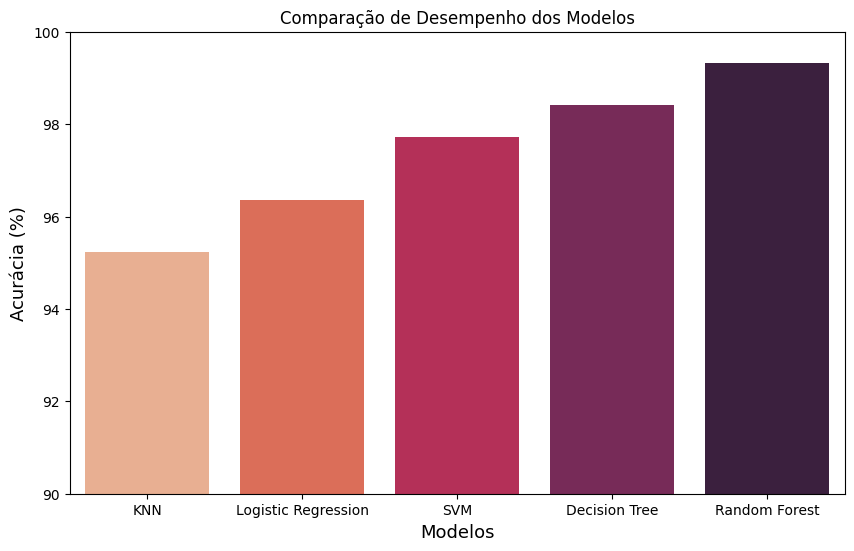

In [ ]:
#gráfico comparativo
resultados_ordenados = resultados.sort_values(by='Acurácia', ascending=True)
cores = sns.color_palette("rocket_r", n_colors=len(resultados_ordenados))
plt.figure(figsize=(10,6))
ax = sns.barplot(x=resultados_ordenados['Modelo'], y=resultados_ordenados['Acurácia'], palette=cores)
plt.title("Comparação de Desempenho dos Modelos")
plt.xlabel("Modelos", fontsize=13)
plt.ylabel("Acurácia (%)", fontsize=13)
plt.ylim(90,100)
plt.show()

Como vemos no gráfico acima, o modelo Random Forest apresentou a maior acurácia entre os algoritmos testados, demonstrando maior capacidade de identificar corretamente as culturas agrícolas com base nos atributos de solo e clima.

Já as análises exploratórias mostraram forte relação entre variáveis ambientais e o tipo de cultura, especialmente temperatura, umidade e nutrientes NPK.

---